# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-3-'
comment = "sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_pM_fold,max_pE_fold,T_pM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
0,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.000000,20.000000,20.000000,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
104,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.000000,20.000000,20.000000,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
208,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.000000,20.000000,20.000000,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
312,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.000000,20.000000,20.000000,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
416,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.693147,0.000000,0.0,0.000000,20.000000,20.000000,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32304583,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,4.868062e+06,441.830836,1.541873,0.778305,3.786348,0.0,16.160000,8.863567,0.533333,0.217911,1.203140,0.003395,5.027427e+06,0.69897,2.624336,0.190305,0.000221
32304687,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,4.867146e+06,508.406103,1.598040,0.843003,4.380237,0.0,16.160000,9.797744,-0.970000,0.217860,1.203007,0.005703,5.028299e+06,0.69897,2.624336,0.190763,0.000254
32304791,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.861115e+06,988.937357,1.952082,1.471707,6.347979,0.0,16.156667,9.868722,-0.616667,0.217527,1.202136,0.010161,5.033854e+06,0.69897,2.624336,0.193778,0.000494
32304895,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,4.773306e+06,7711.812181,3.897789,3.974246,10.770127,0.0,16.236667,9.053456,-2.293333,0.213106,1.188769,0.067797,5.106947e+06,0.69897,2.624336,0.237683,0.003856


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

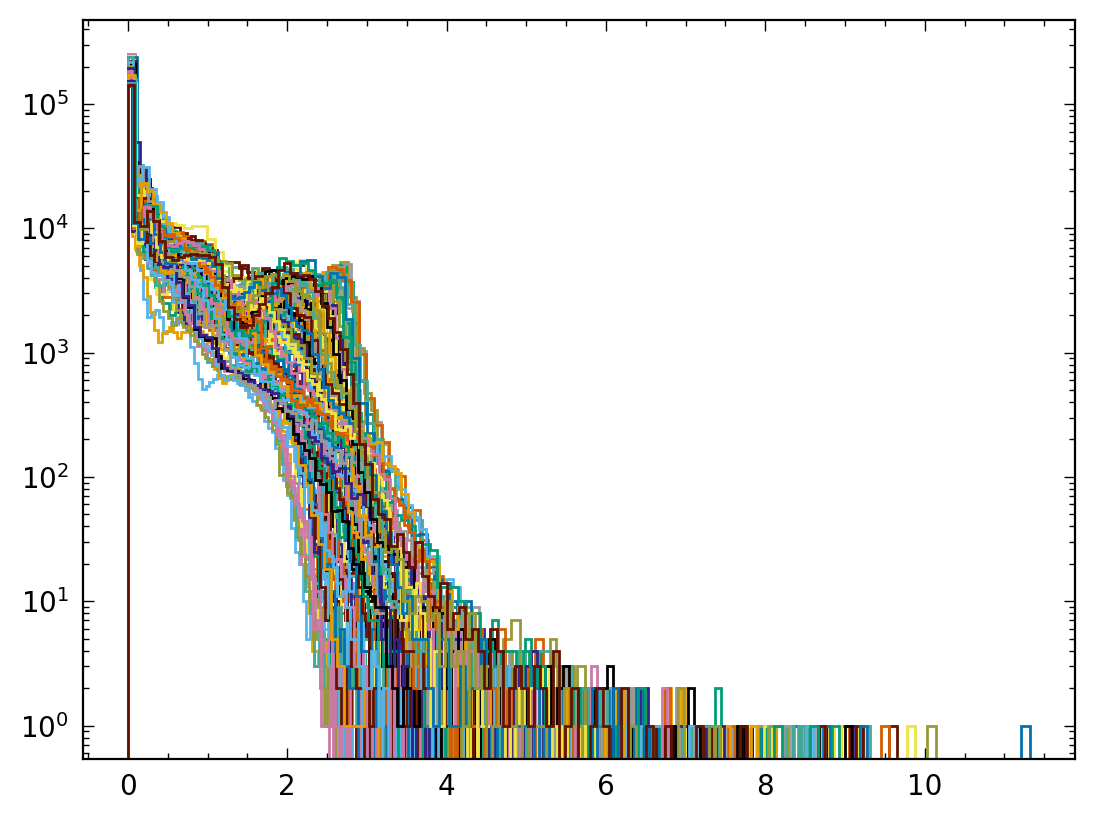

In [4]:
# Inspect distribution of observables
sel = 'stim_pP'
for a in np.unique(clustered_mean_df[key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,0.698970,0.206799,1.159472,0.082419
1,0.716313,0.279635,1.356632,0.109740
2,0.734707,0.345308,1.481985,0.136395
3,0.754414,0.418584,1.588780,0.165870
4,0.754888,0.325626,1.162055,0.097066
...,...,...,...,...
95,2.397940,3.960237,1.559561,0.416365
96,2.477121,4.191586,1.619719,0.457879
97,2.568202,4.441265,1.671991,0.498502
98,2.676694,4.723588,1.721495,0.539352


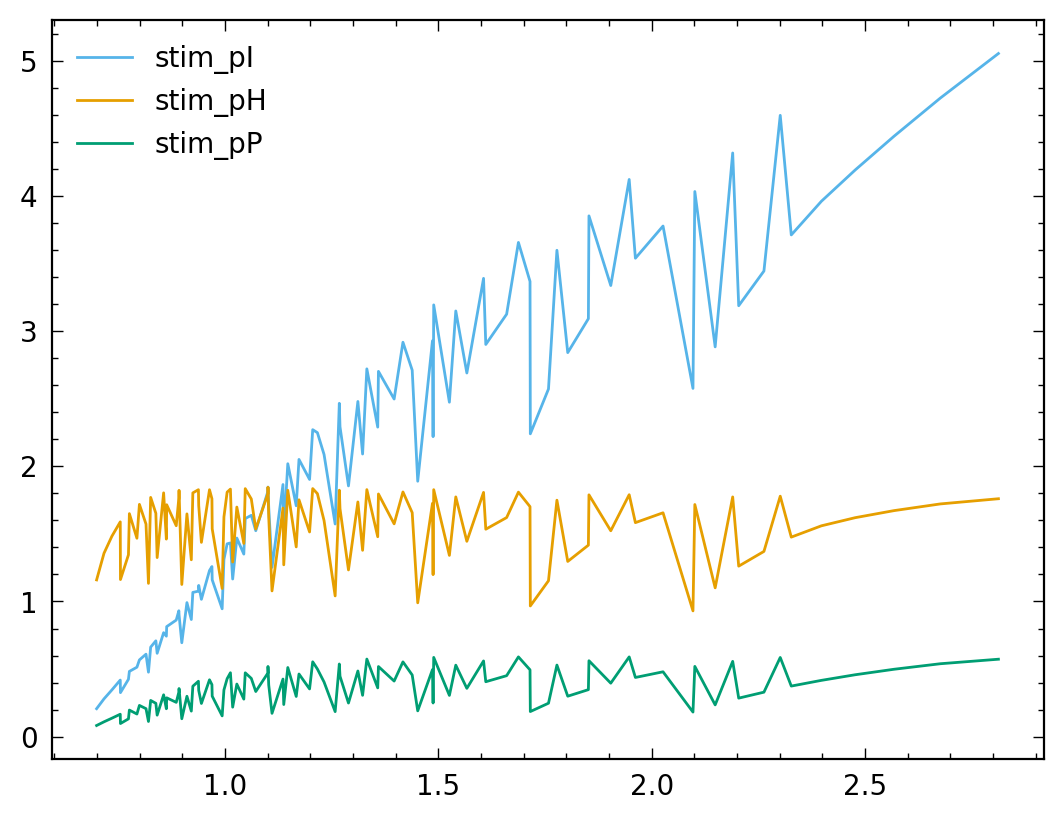

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 10
fevals: 11
fevals: 10
fevals: 67


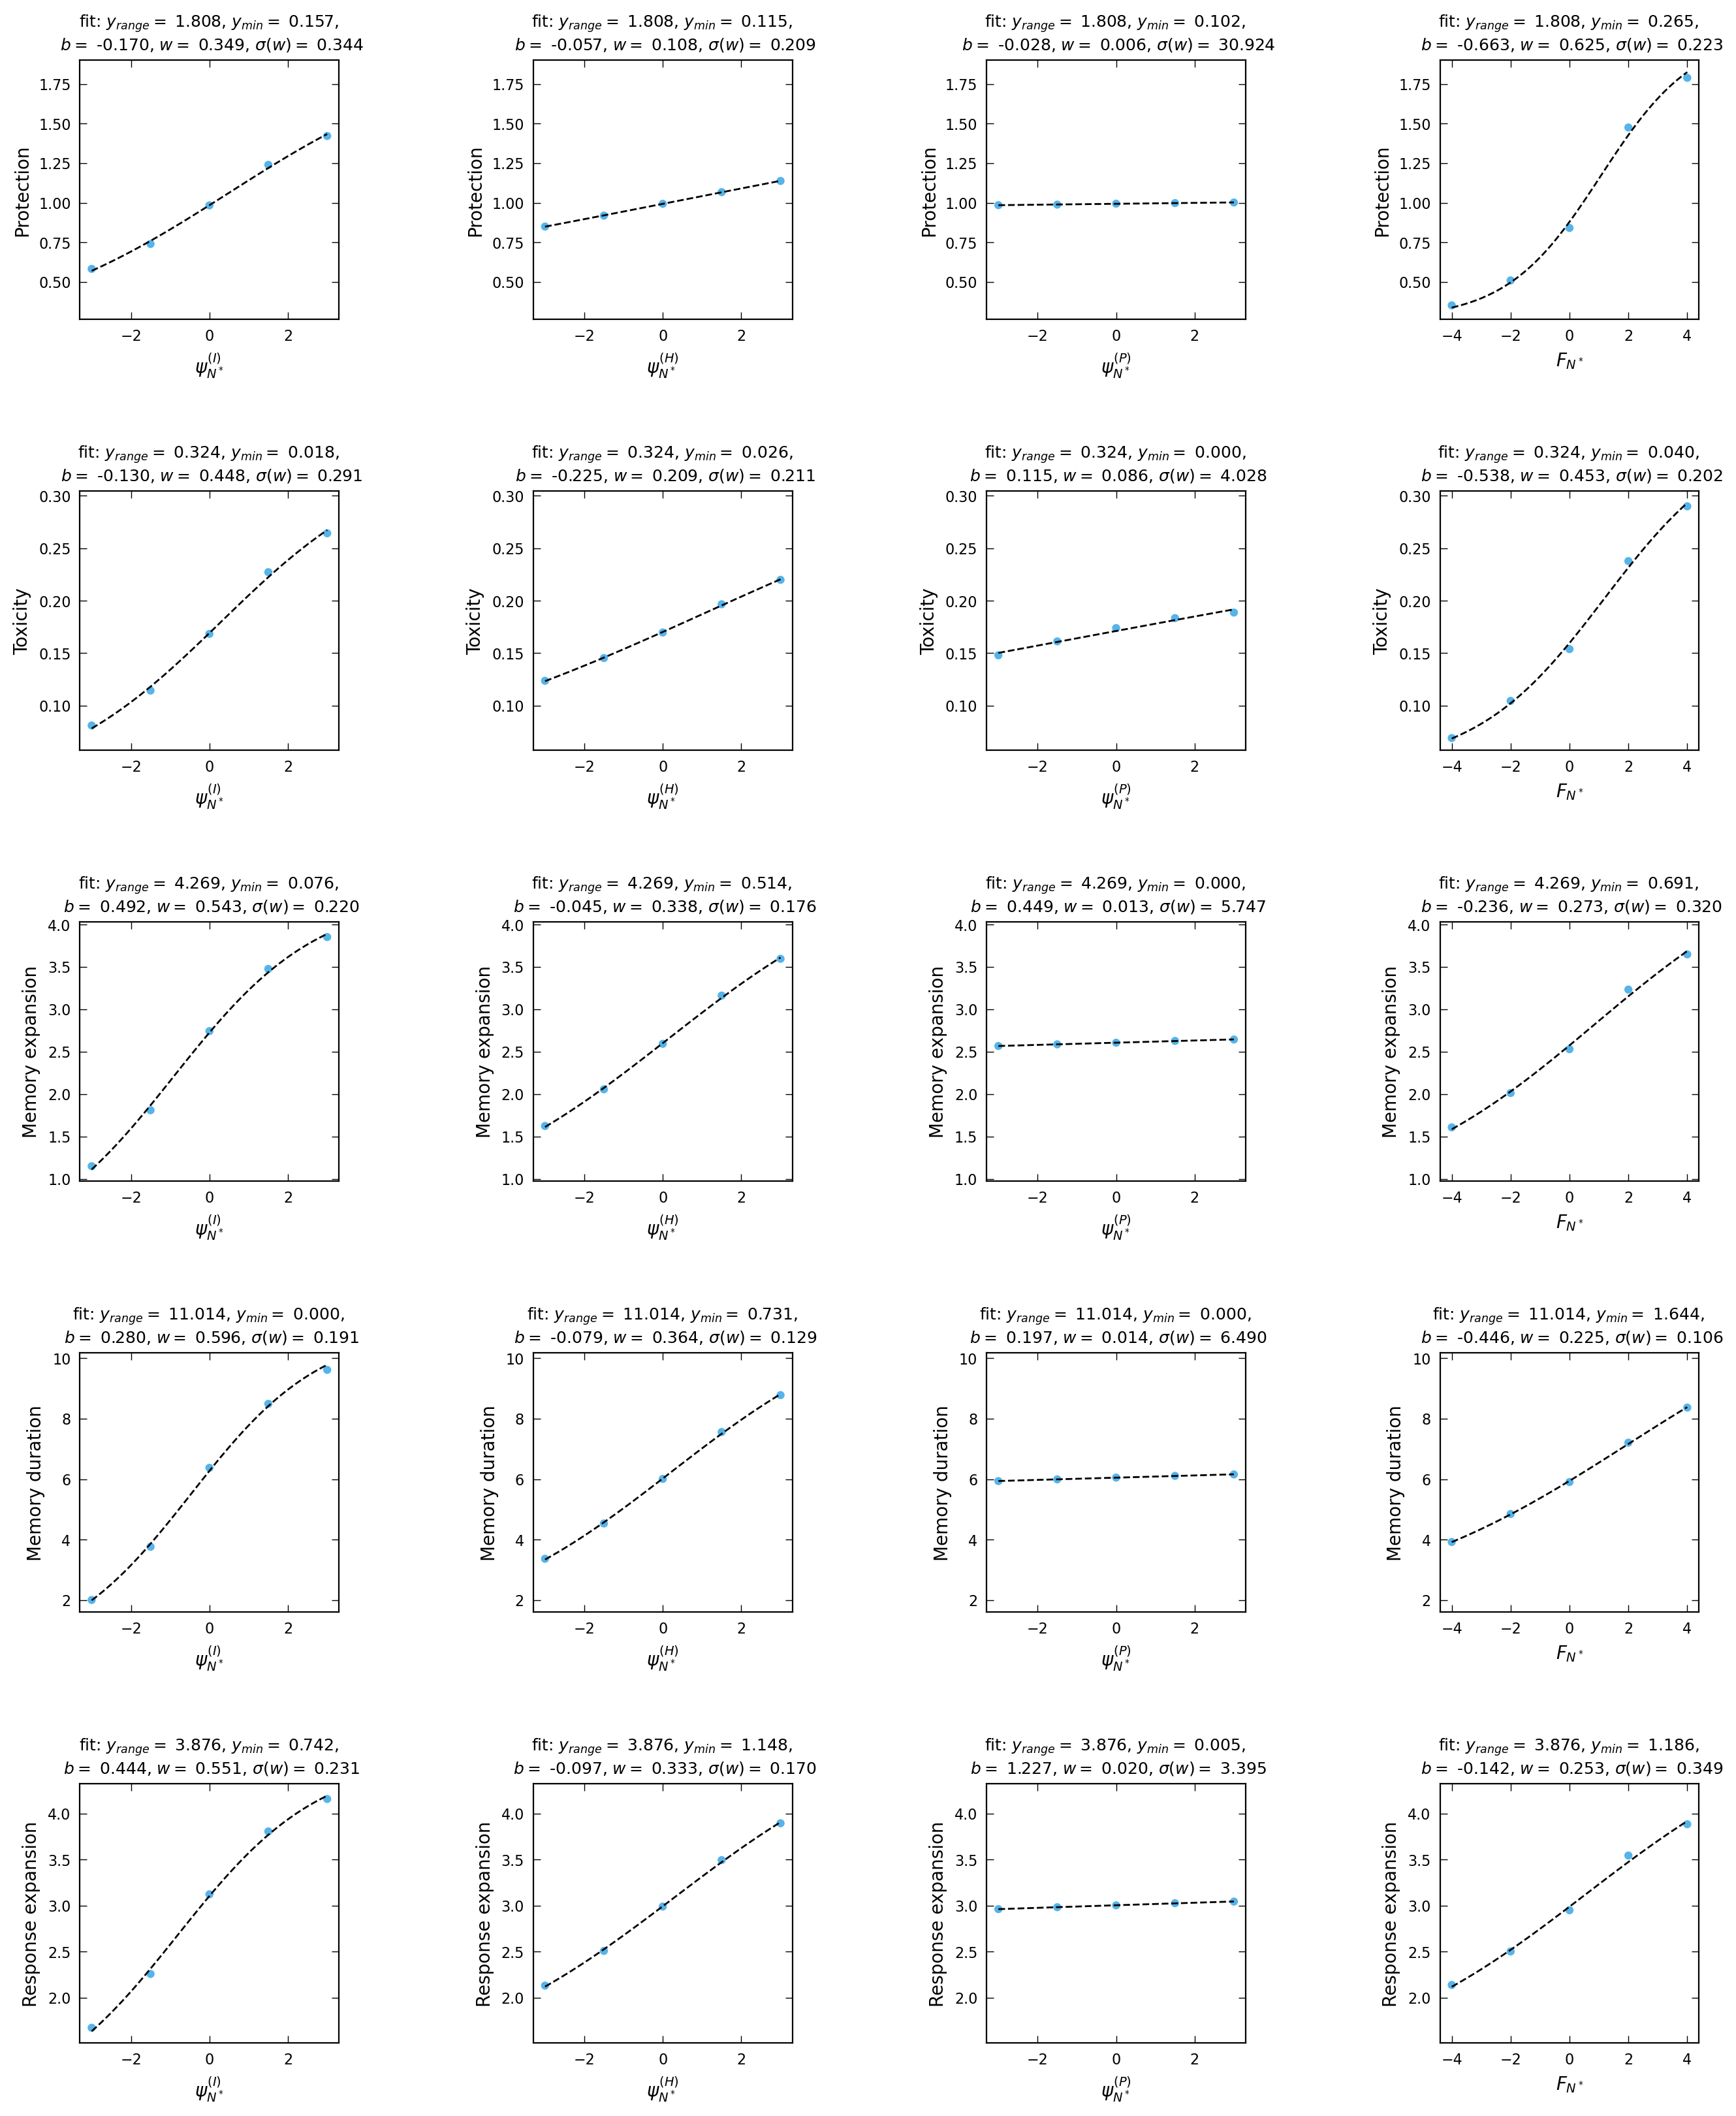

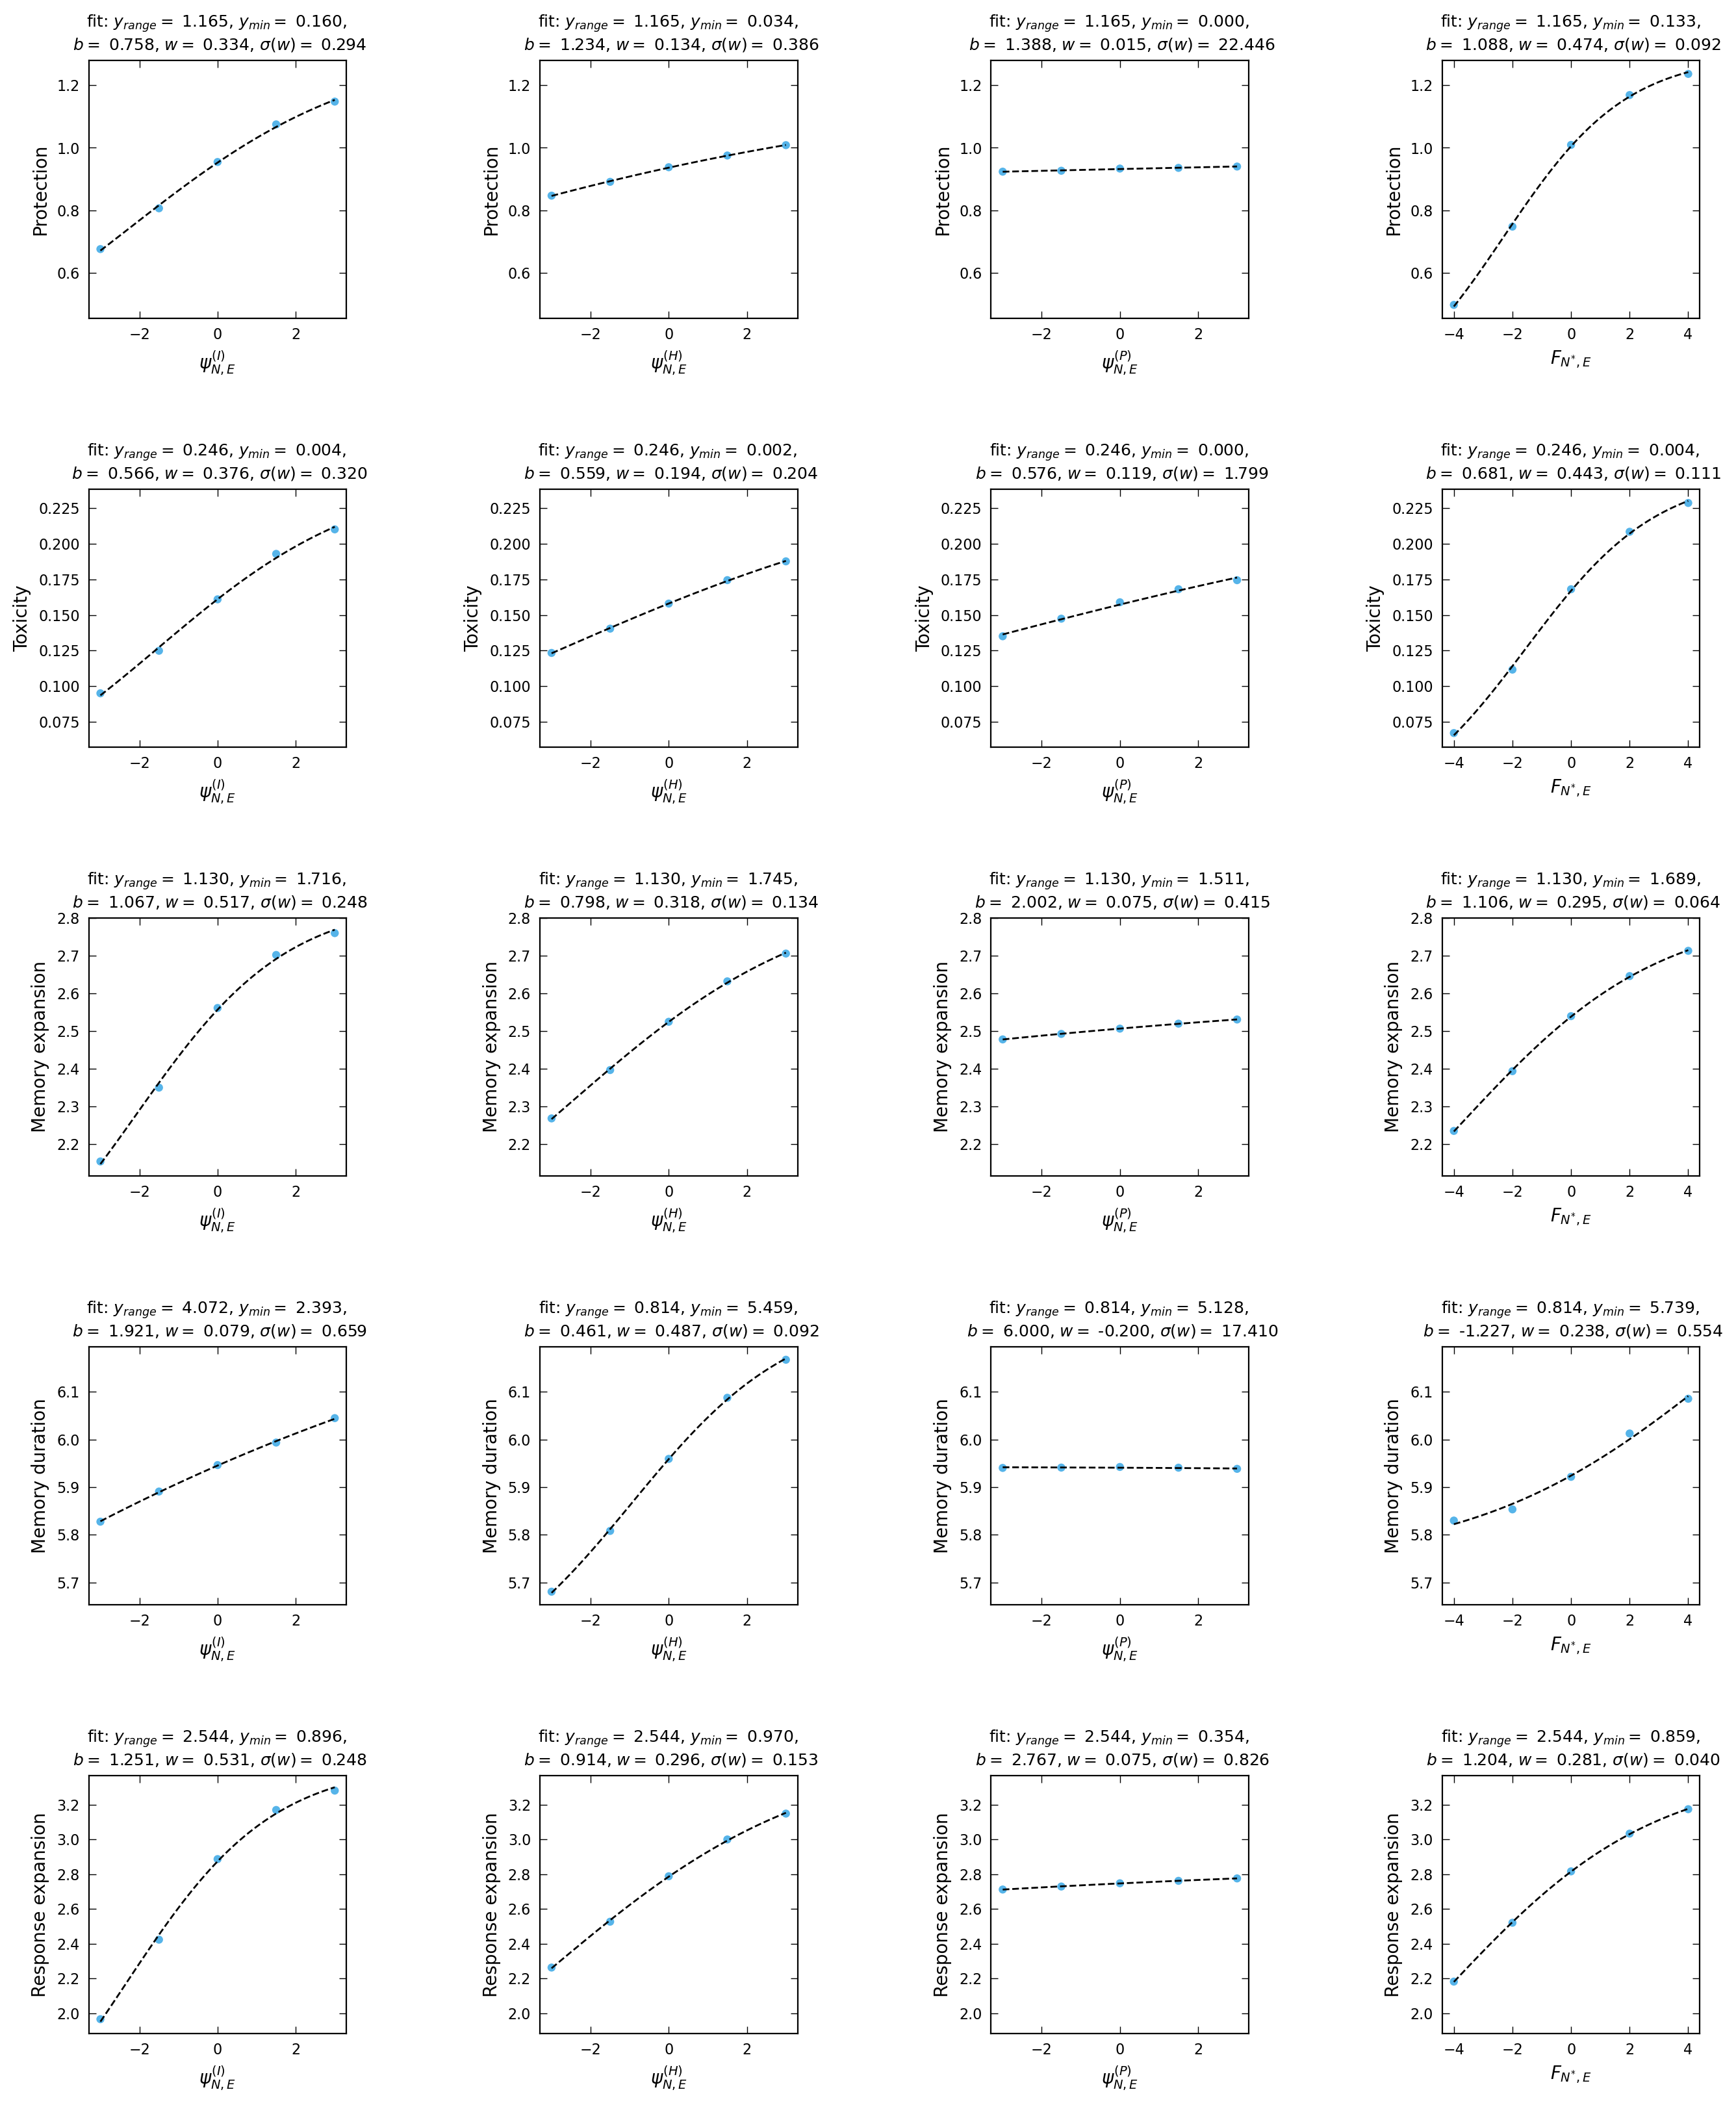

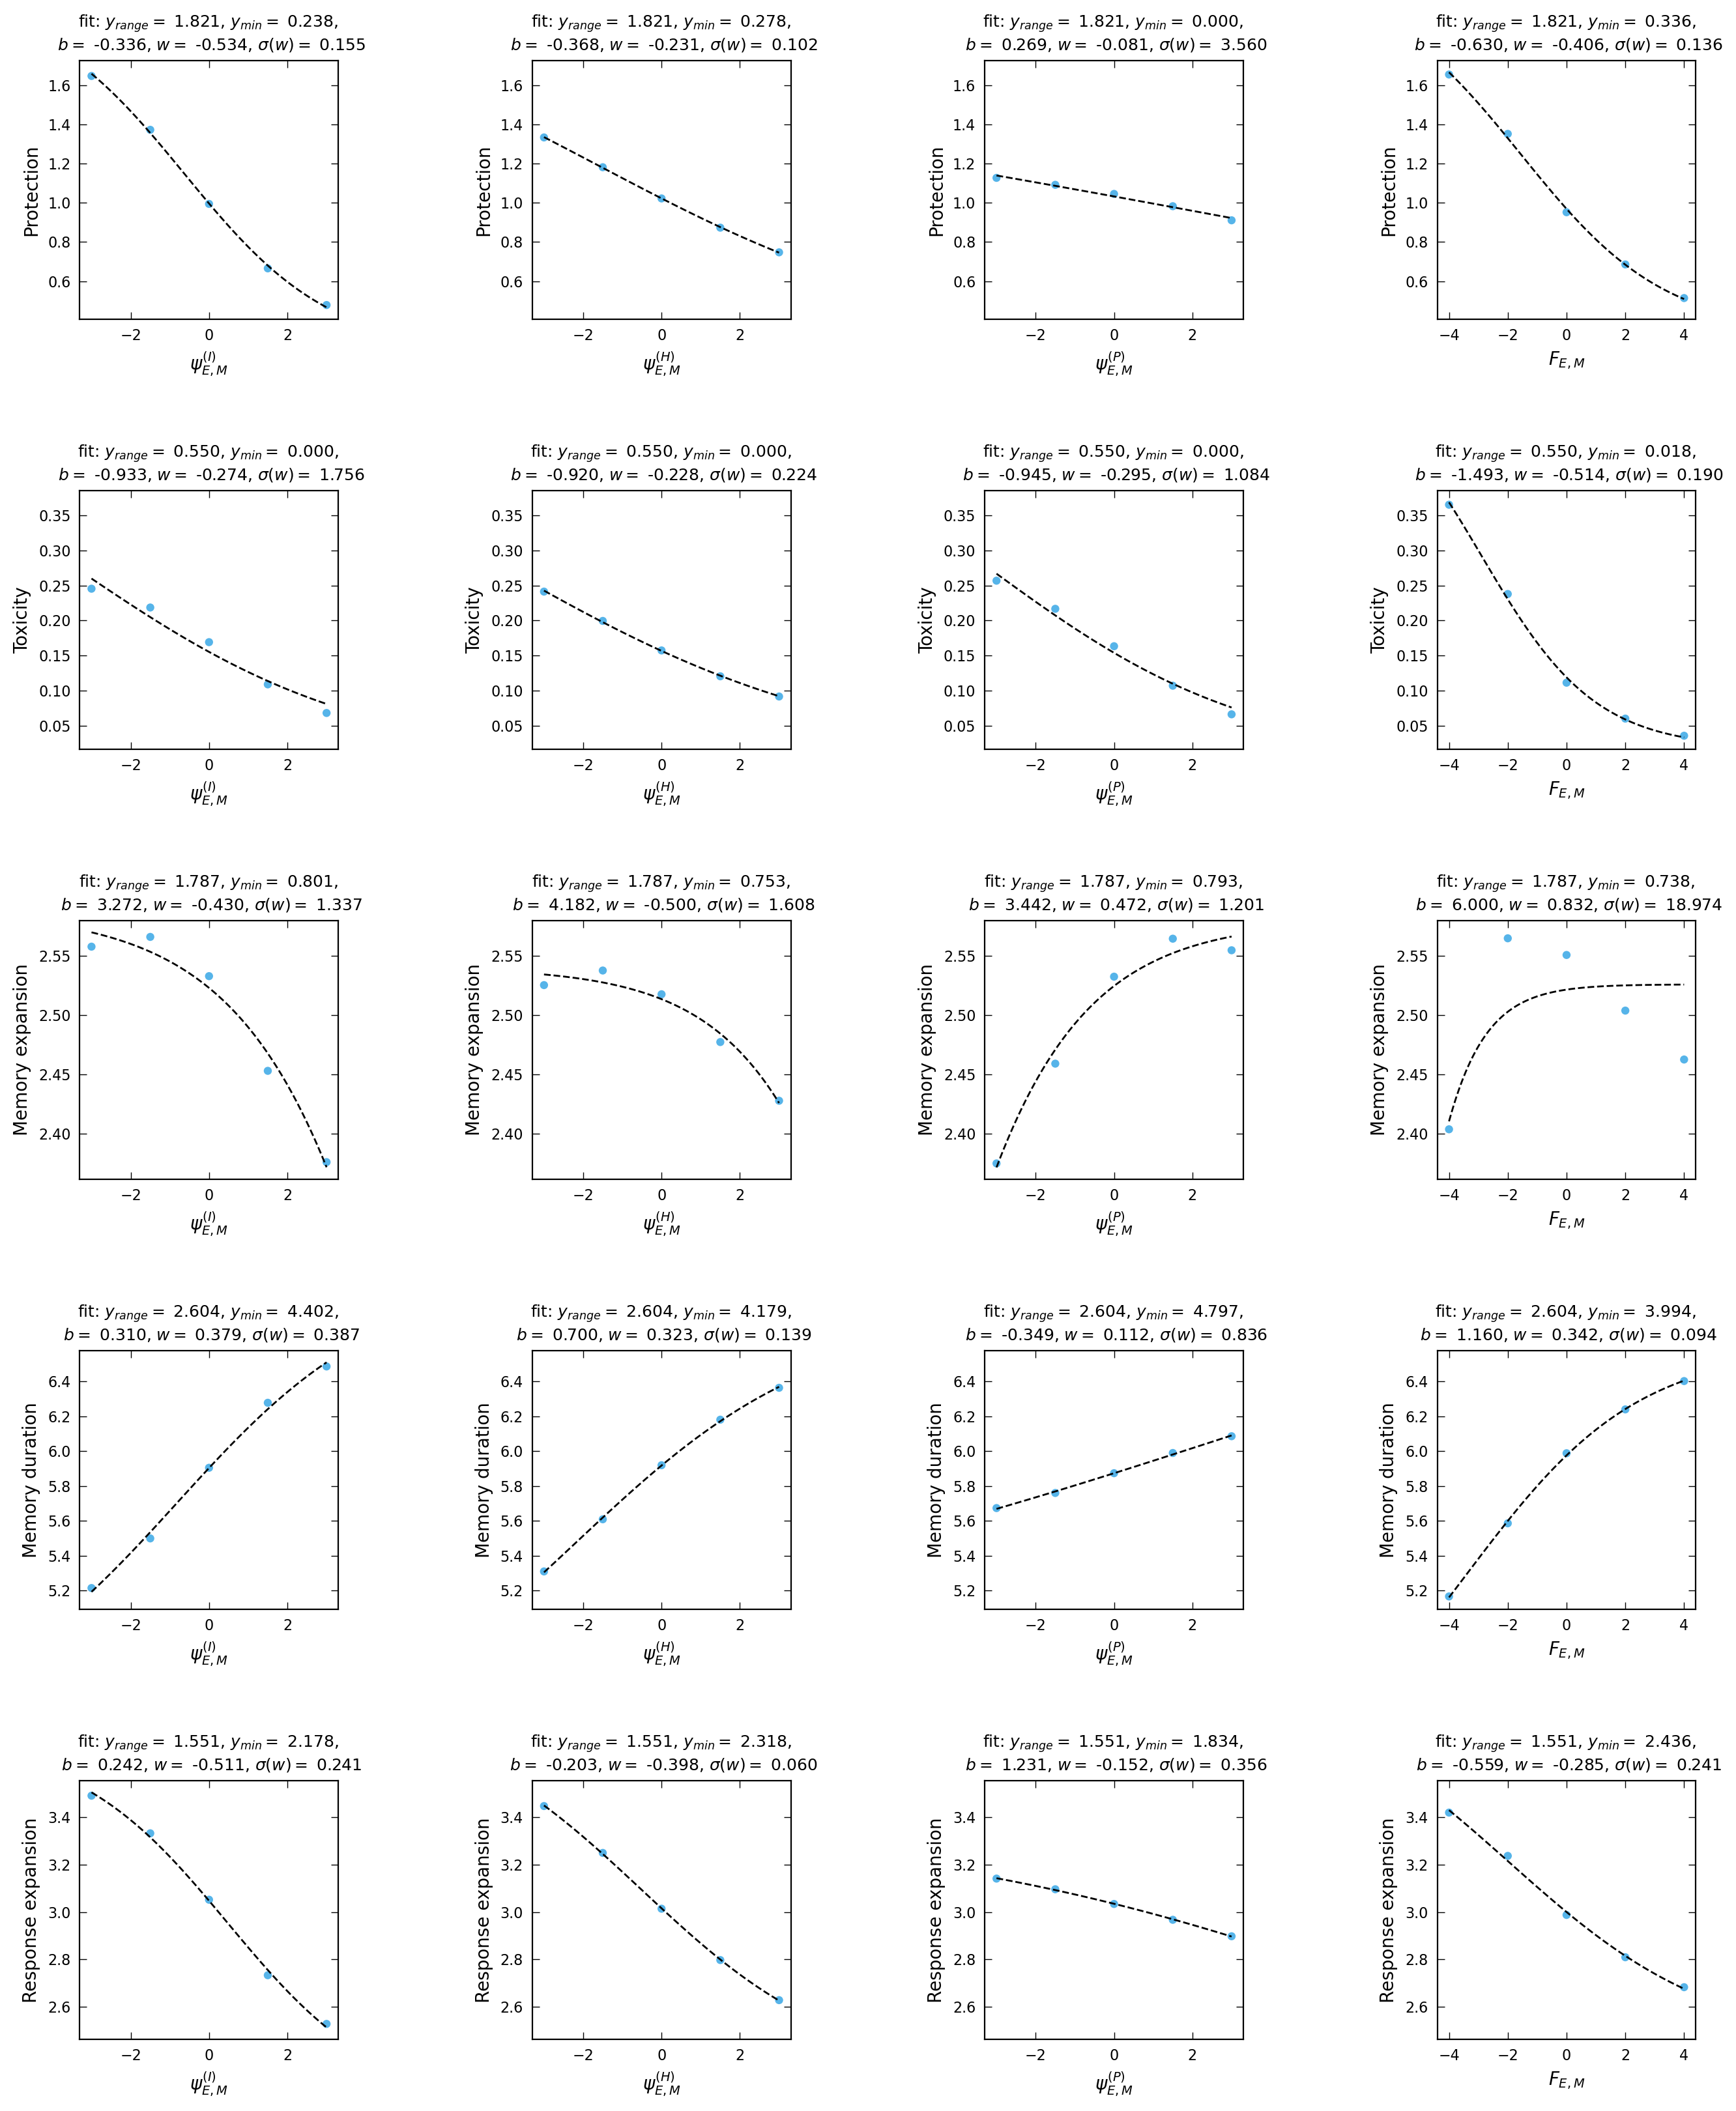

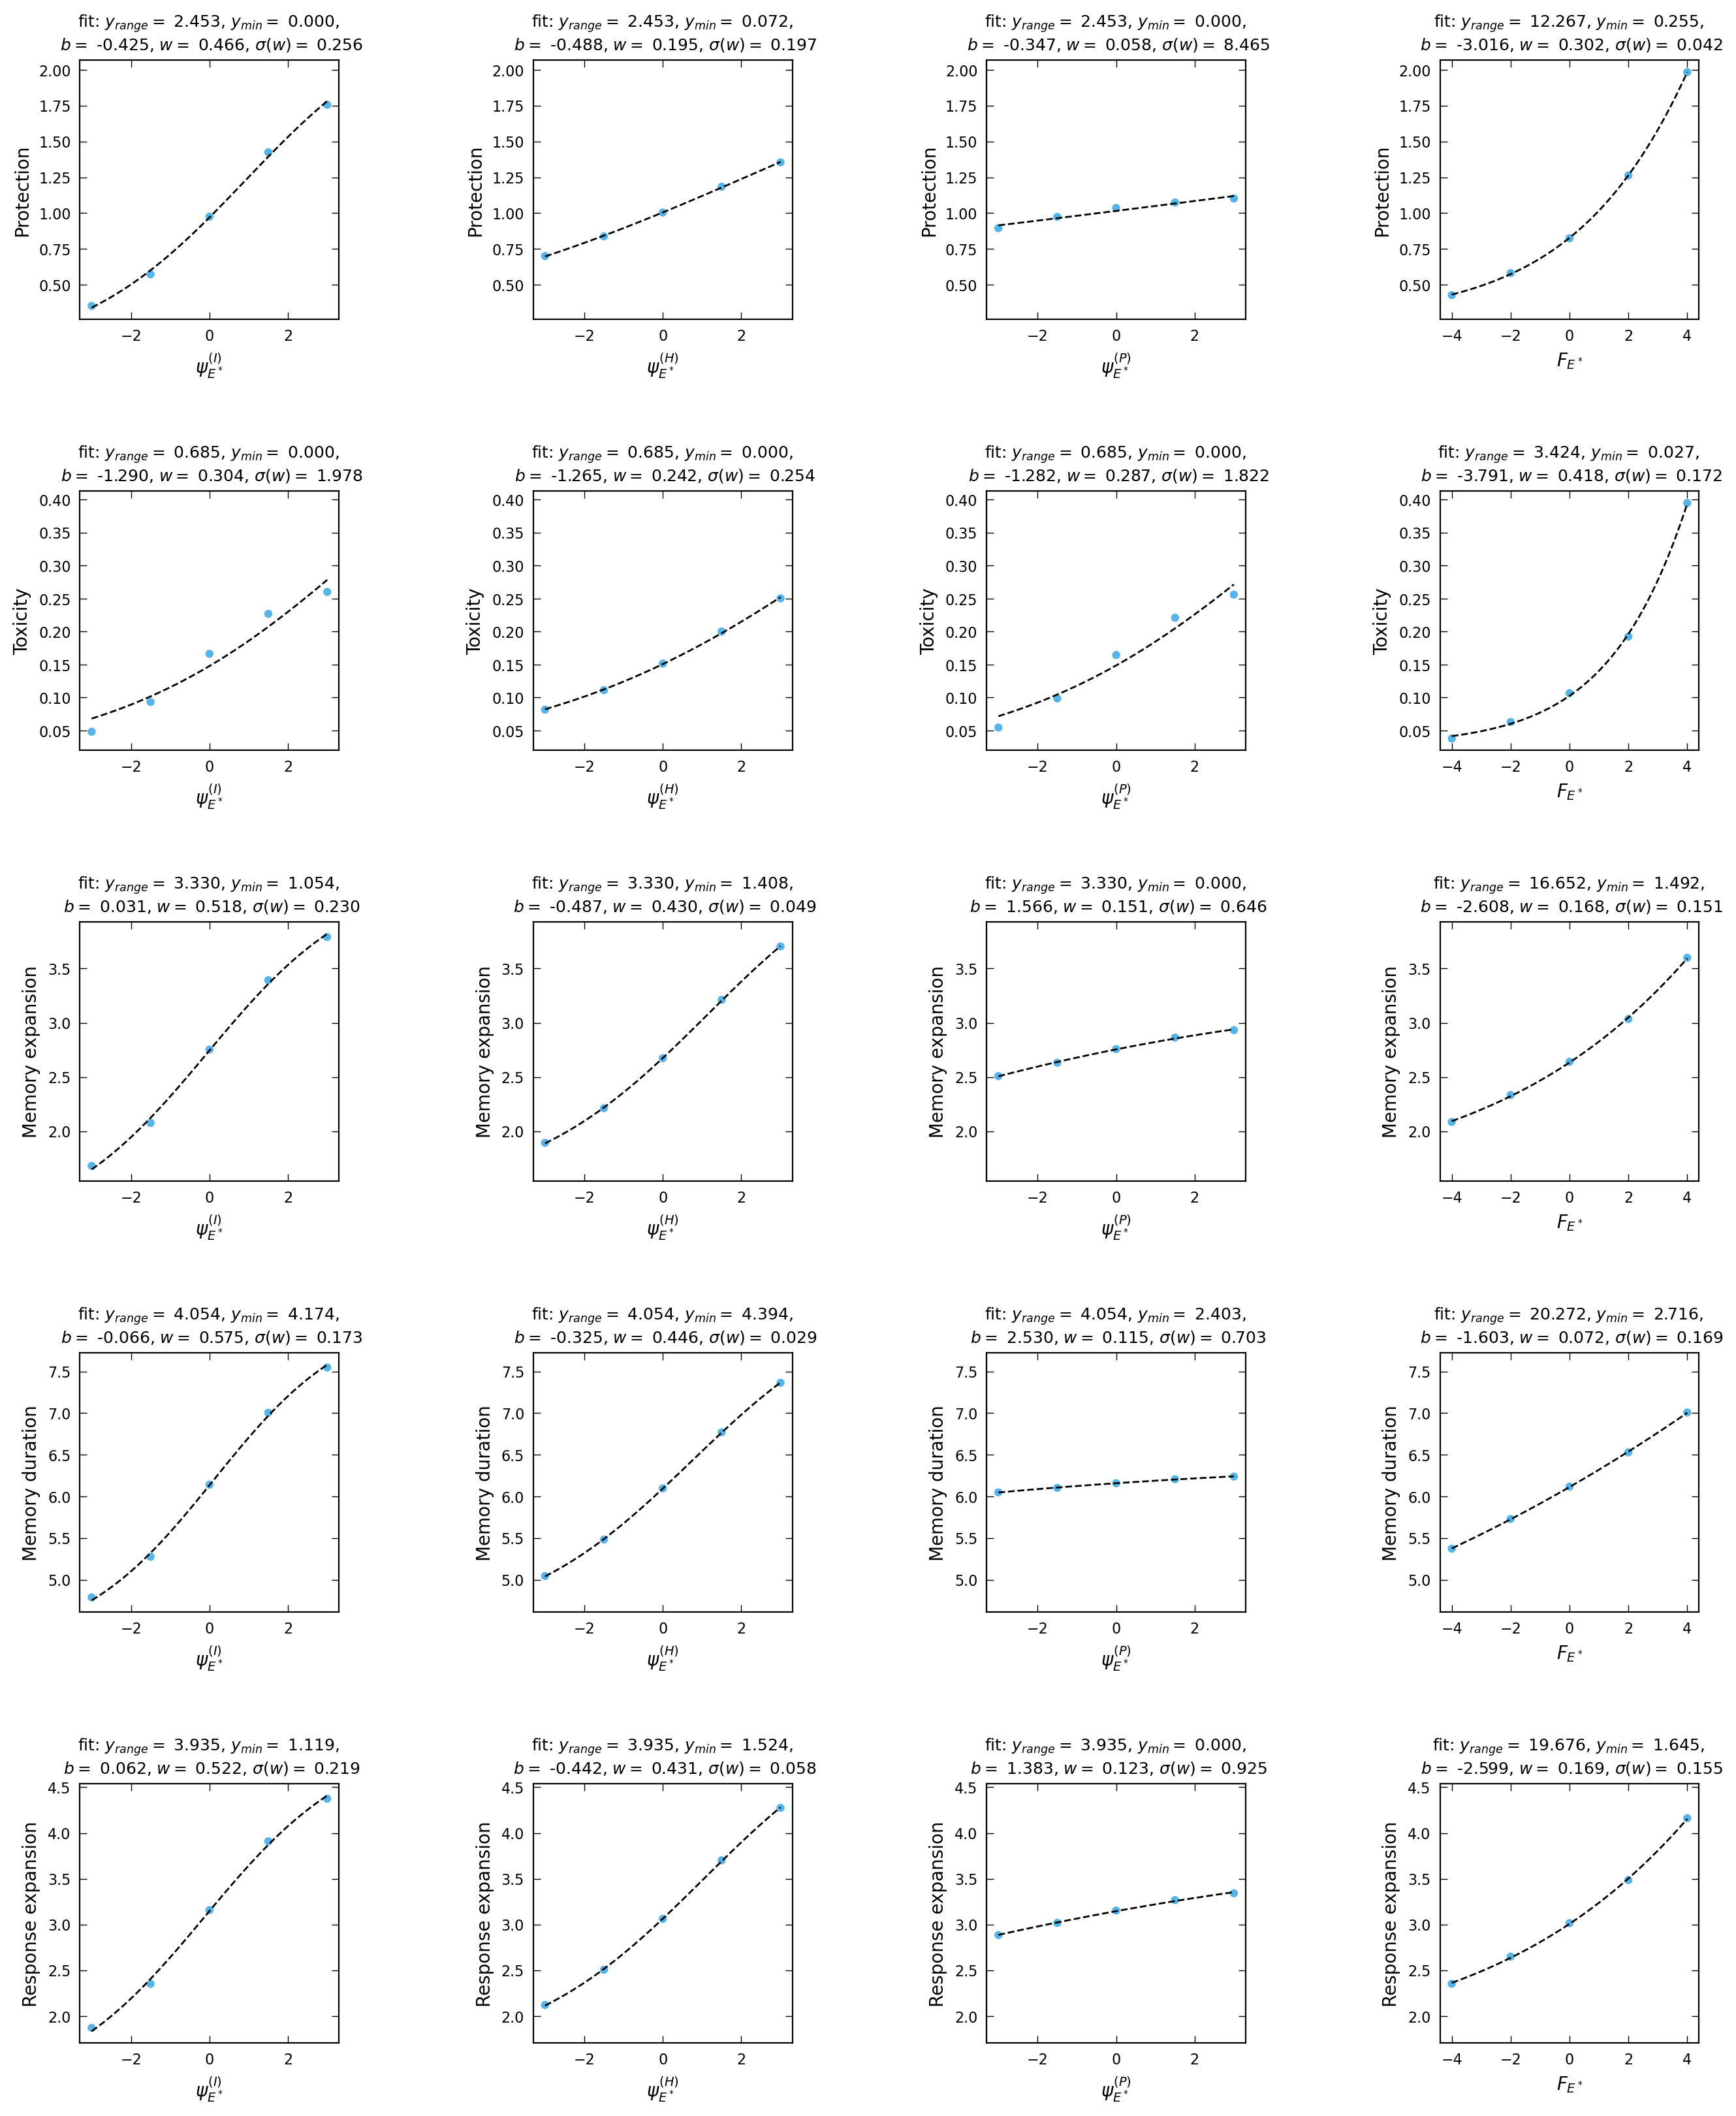

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[clustered_mean_df.K_EH == K_EH].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 104
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0 if y_min > 0.0 else y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_min, 0.0] + len(variables)*[-2.5*F0_max] + num_modules*[-2.5*F0_max], 
                                     [2.0*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[2.5*F0_max] + num_modules*[2.5*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [28]:
# View result
perf = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,5.642723,1.564671e-19,1.351561,0.246750,0.560720,2.080053,0.638750,0.151711,0.423183,0.997960,-1.185620,-0.041396,-1.561967,-1.931298,1.121645,0.064969,1.156133,1.878385,1.429353,2.671358,-2.452867,-3.811757,0.005221,0.000475,0.005599,0.003578,0.003908,0.006742,0.003479,0.002929,0.003171,0.003063,0.004012,0.002708,0.004751,0.004764,0.005265,0.002287,0.005370,0.007970,0.005694,0.009315,0.007502,0.015179,0.01,1.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.267965,5.242680,0.0,8.033168e-04,1.0,0.238518,0.933695,0.000000,0.669218,0.060883,0.382092,0.999456
6,3.541047,2.914321e-14,0.385132,0.179266,0.646365,2.371191,0.164118,0.024793,0.489392,0.929146,-0.361468,-0.005806,-1.087903,-1.796501,0.355790,0.021753,0.963967,2.029156,0.279607,1.568061,-2.992406,-6.908899,0.003806,0.000109,0.002906,0.002516,0.003456,0.009981,0.001695,0.001667,0.001909,0.001811,0.001772,0.001610,0.002815,0.003781,0.001288,0.001153,0.001912,0.003153,0.002273,0.004324,0.006864,0.009631,0.01,5.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.066289,3.168994,0.0,0.000000e+00,1.0,0.057471,0.327953,0.000000,0.179604,0.060883,0.094503,0.850787
11,5.413660,1.383208e-17,1.194135,0.779026,0.540399,1.911421,0.560155,0.449160,0.336199,0.969450,-1.146986,-0.172547,-1.537240,-1.925200,1.012280,0.228923,1.155144,1.761937,1.613759,2.604539,-2.442503,-3.619914,0.005621,0.000492,0.005157,0.004352,0.004006,0.005857,0.003587,0.003419,0.003275,0.003206,0.004226,0.002941,0.005034,0.005099,0.004903,0.002554,0.005403,0.007533,0.006915,0.009848,0.008021,0.014188,0.05,1.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.260947,4.997497,0.0,8.795151e-04,1.0,0.245778,0.897490,0.000000,0.647097,0.267120,0.358488,0.822509
16,3.391522,9.951792e-18,0.392964,0.501914,0.663426,2.109278,0.153646,0.098348,0.460470,0.924801,-0.348688,-0.042574,-1.061483,-1.784490,0.334244,0.075183,0.971756,2.059252,0.366056,1.571832,-2.968649,-6.999909,0.003657,0.000106,0.002671,0.002904,0.003262,0.007438,0.001692,0.001677,0.001885,0.001809,0.001759,0.001610,0.002764,0.003739,0.001287,0.001172,0.001943,0.003257,0.002340,0.004345,0.006771,0.009959,0.05,5.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.064381,3.135410,0.0,8.231964e-07,1.0,0.055739,0.316762,0.000000,0.172311,0.267120,0.101357,0.700161
21,10.015165,1.758228e-39,1.831097,0.211301,0.195166,1.372538,1.271807,0.213983,0.204076,0.934499,-0.999380,-0.343094,-0.805444,-1.052945,1.417522,0.405433,0.861475,1.190361,0.279186,1.672586,-2.201857,-2.297173,0.019387,0.000813,0.009002,0.003870,0.003853,0.006273,0.006472,0.003996,0.003987,0.003745,0.004233,0.002700,0.003699,0.003617,0.005813,0.003124,0.004170,0.004281,0.004527,0.009052,0.005758,0.007080,0.25,1.000000e+04,1.500000e-07,50000.0,300.0,10000000.0,0.307099,10.015165,0.0,7.969149e-04,1.0,0.397144,1.138760,5.383736,5.053221,1.759867,0.572834,2.812913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,6.014244,1.058330e-02,0.429520,0.513697,0.351266,0.927570,0.171033,0.157598,0.347850,0.910560,-0.224717,-0.221347,-0.791546,-1.642778,0.222376,0.240057,0.681441,1.472593,-0.254541,1.248873,-2.960280,-5.047103,0.015508,0.000278

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

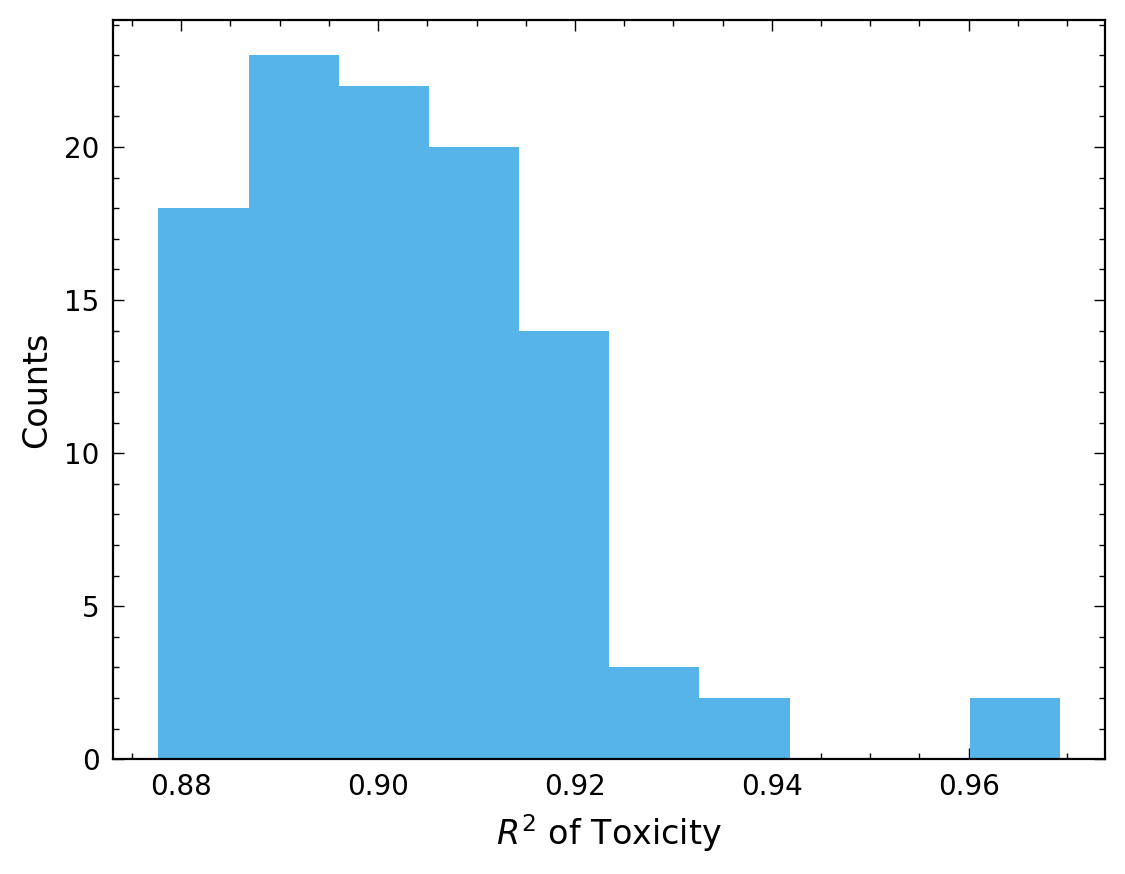

In [29]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

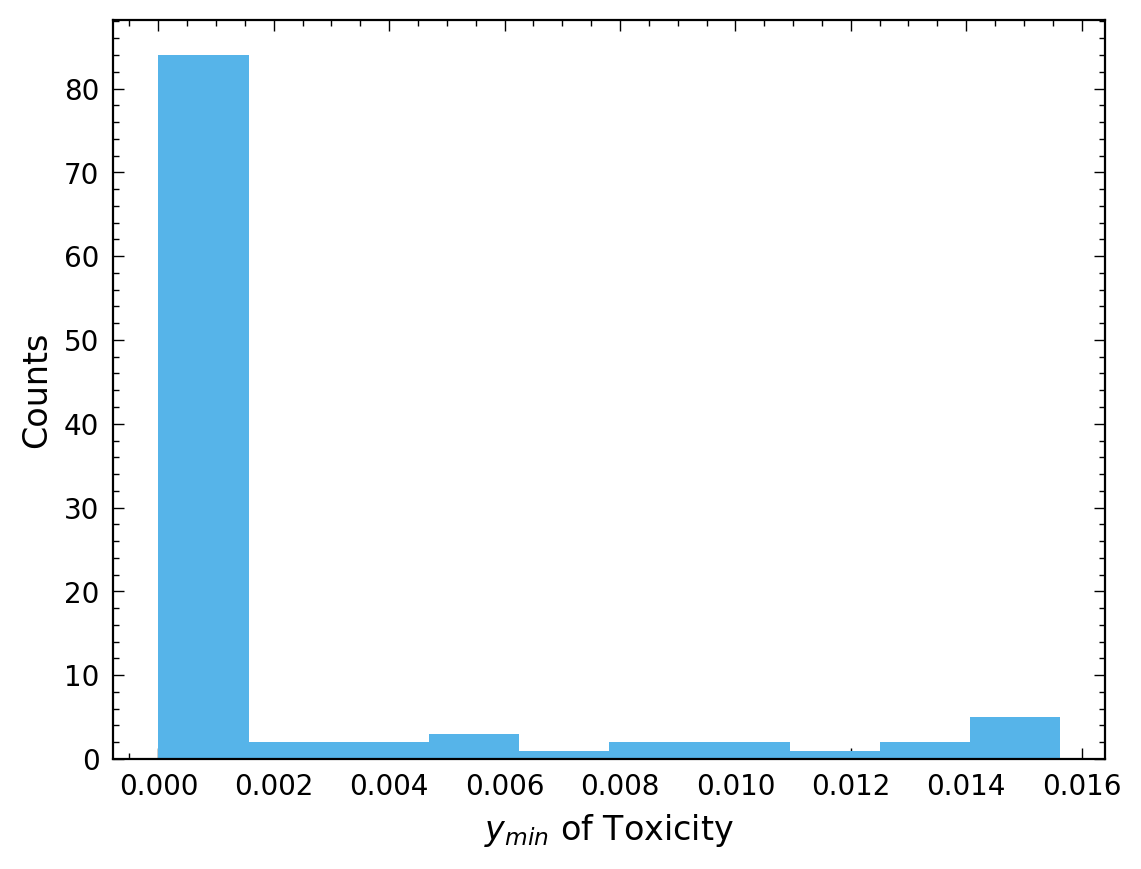

In [30]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

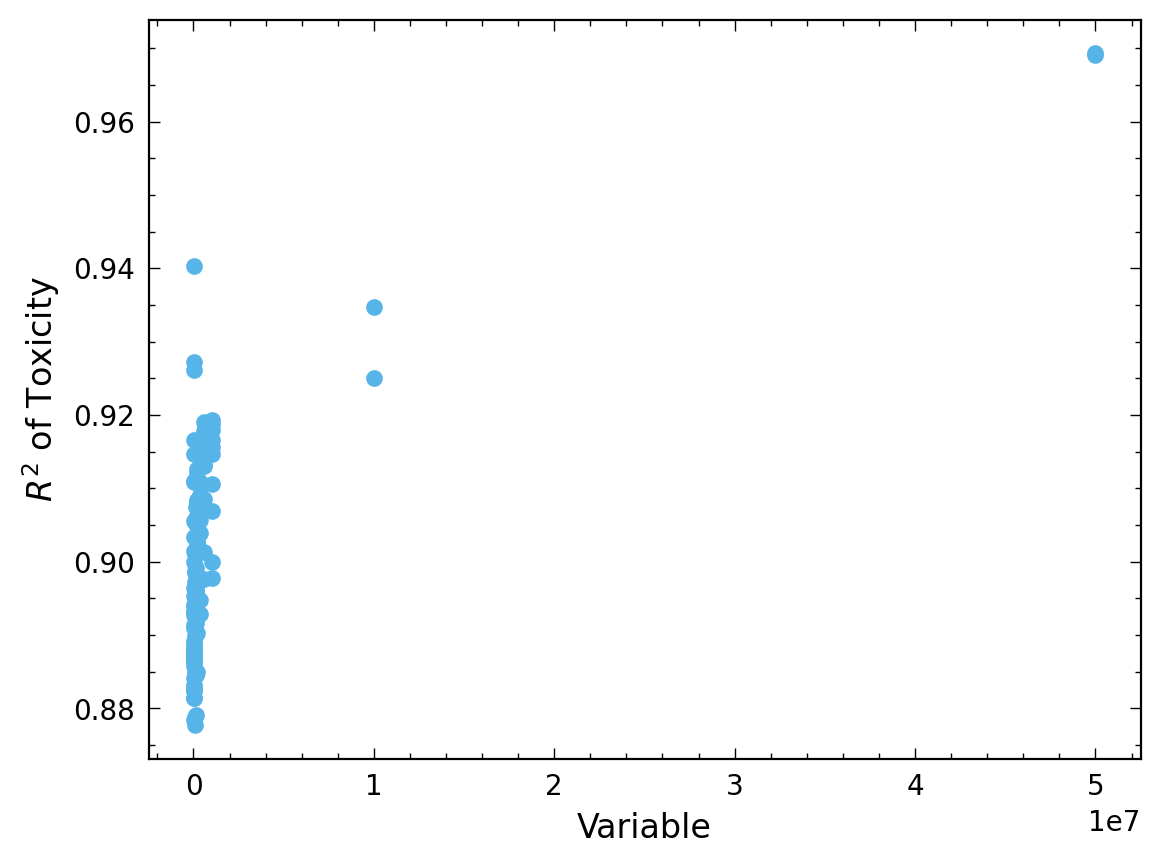

In [31]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].K_IE, model_r_sq);
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

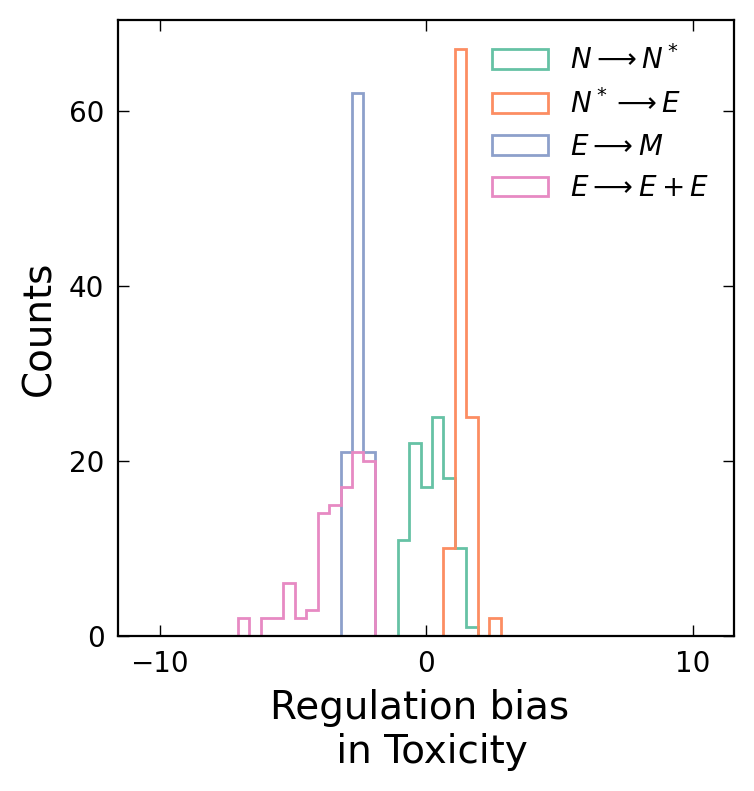

In [32]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

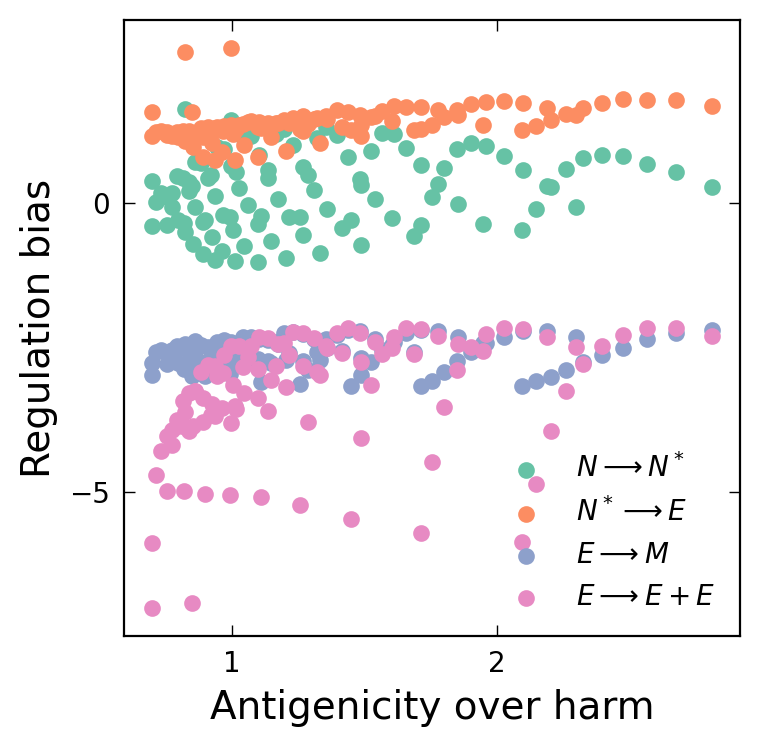

In [33]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

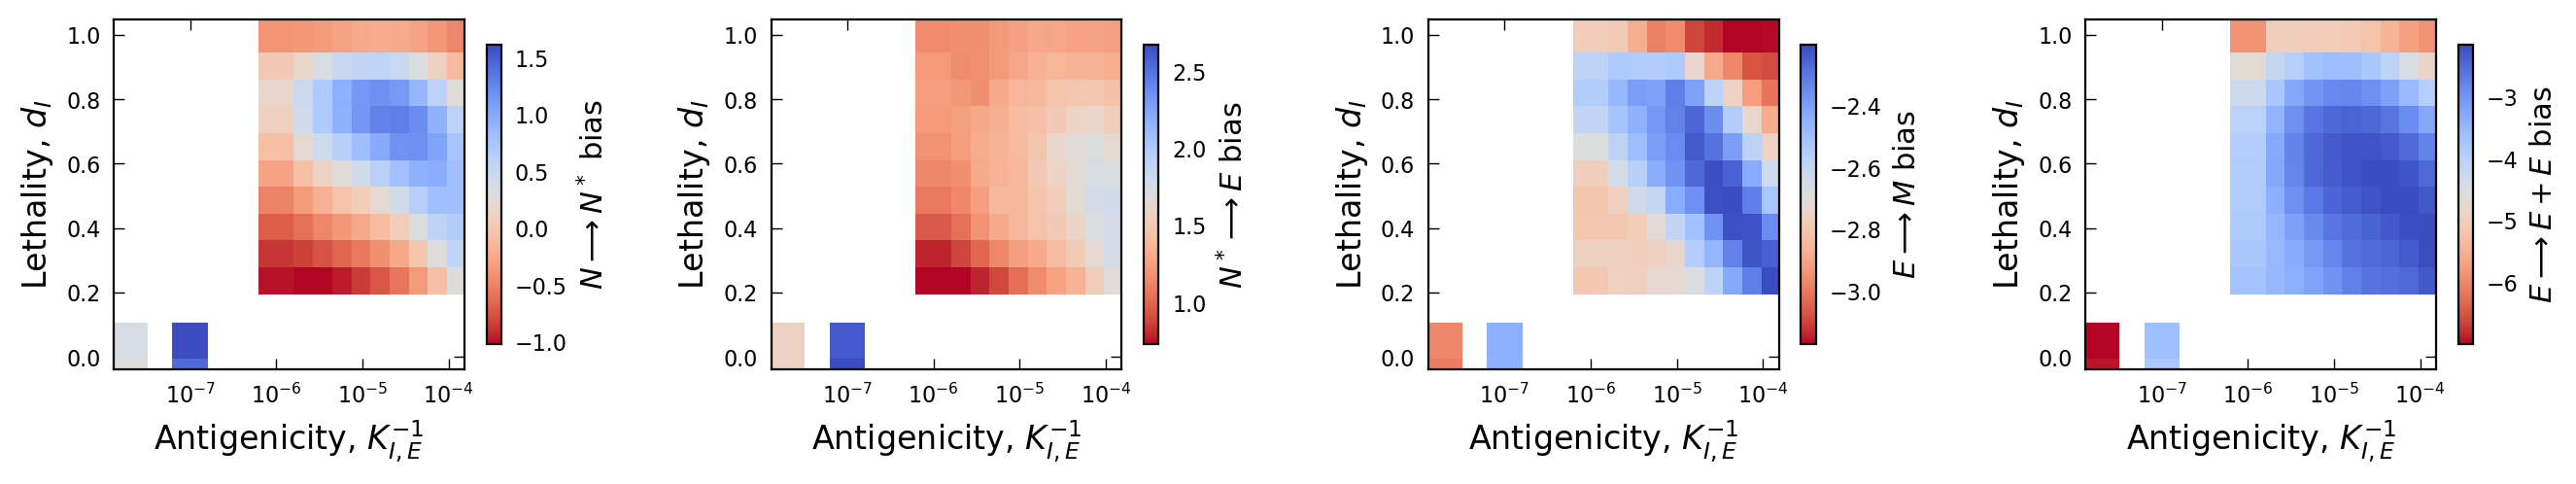

In [34]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

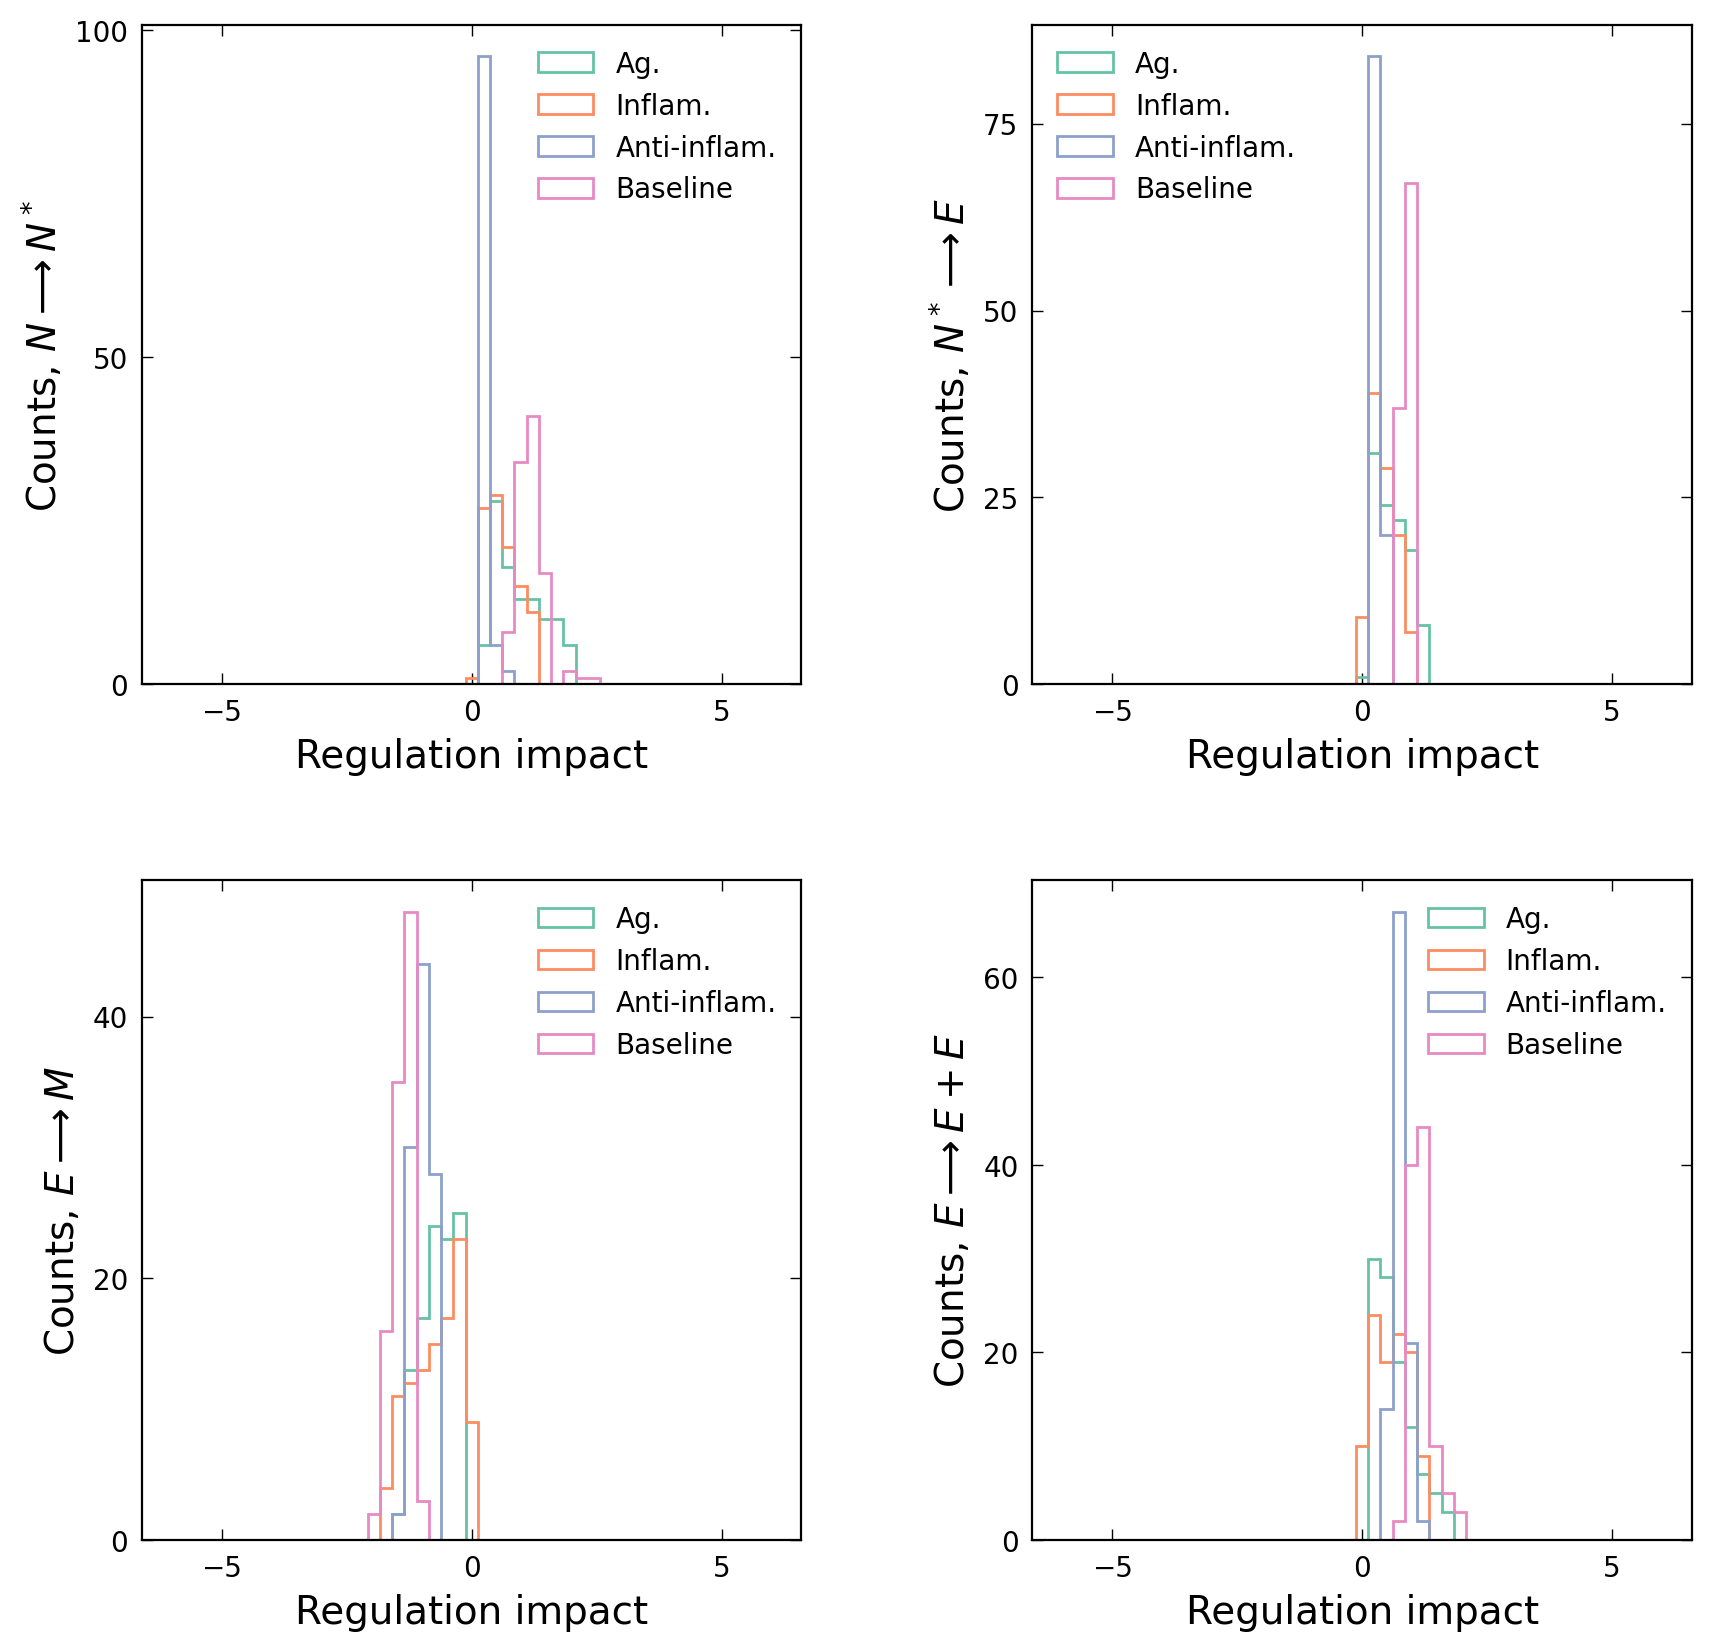

In [35]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-2.0*psi_max, 2.0*psi_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [36]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,5.642723,1.564671e-19,1.351561,0.246750,0.560720,2.080053,0.638750,0.151711,0.423183,0.997960,-1.185620,-0.041396,-1.561967,-1.931298,1.121645,0.064969,1.156133,1.878385,1.429353,2.671358,-2.452867,-3.811757,0.005221,0.000475,0.005599,0.003578,0.003908,0.006742,0.003479,0.002929,0.003171,0.003063,0.004012,0.002708,0.004751,0.004764,0.005265,0.002287,0.005370,0.007970,0.005694,0.009315,0.007502,0.015179,0.01,10000000.0,0.0,50000.0,300.0,10000000.0,0.267965,5.242680,0.0,8.033168e-04,1.0,0.238518,0.933695,0.0,0.669218,0.060883,0.382092,0.999456
6,3.541047,2.914321e-14,0.385132,0.179266,0.646365,2.371191,0.164118,0.024793,0.489392,0.929146,-0.361468,-0.005806,-1.087903,-1.796501,0.355790,0.021753,0.963967,2.029156,0.279607,1.568061,-2.992406,-6.908899,0.003806,0.000109,0.002906,0.002516,0.003456,0.009981,0.001695,0.001667,0.001909,0.001811,0.001772,0.001610,0.002815,0.003781,0.001288,0.001153,0.001912,0.003153,0.002273,0.004324,0.006864,0.009631,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.066289,3.168994,0.0,0.000000e+00,1.0,0.057471,0.327953,0.0,0.179604,0.060883,0.094503,0.850787
11,5.413660,1.383208e-17,1.194135,0.779026,0.540399,1.911421,0.560155,0.449160,0.336199,0.969450,-1.146986,-0.172547,-1.537240,-1.925200,1.012280,0.228923,1.155144,1.761937,1.613759,2.604539,-2.442503,-3.619914,0.005621,0.000492,0.005157,0.004352,0.004006,0.005857,0.003587,0.003419,0.003275,0.003206,0.004226,0.002941,0.005034,0.005099,0.004903,0.002554,0.005403,0.007533,0.006915,0.009848,0.008021,0.014188,0.05,10000000.0,0.0,50000.0,300.0,10000000.0,0.260947,4.997497,0.0,8.795151e-04,1.0,0.245778,0.897490,0.0,0.647097,0.267120,0.358488,0.822509
16,3.391522,9.951792e-18,0.392964,0.501914,0.663426,2.109278,0.153646,0.098348,0.460470,0.924801,-0.348688,-0.042574,-1.061483,-1.784490,0.334244,0.075183,0.971756,2.059252,0.366056,1.571832,-2.968649,-6.999909,0.003657,0.000106,0.002671,0.002904,0.003262,0.007438,0.001692,0.001677,0.001885,0.001809,0.001759,0.001610,0.002764,0.003739,0.001287,0.001172,0.001943,0.003257,0.002340,0.004345,0.006771,0.009959,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.064381,3.135410,0.0,8.231964e-07,1.0,0.055739,0.316762,0.0,0.172311,0.267120,0.101357,0.700161
